# Prédiction du nombre d'exacerbations annuelles chez les patients asthmatiques

---

# I/ INTRODUCTION

Ce script constitue la partie 2 du projet, complémentaire à la partie 1 (classification binaire).
Tandis que la partie 1 prédit la survenue d'une exacerbation (oui/non), ce script prédit le nombre
d'exacerbations survenant dans l'année (`post_index_exacerbations365`).

### Pourquoi ne pas utiliser une régression classique ?

Une régression linéaire produirait des valeurs négatives ou décimales, incohérentes pour un comptage.
Elle suppose aussi des erreurs normalement distribuées, inadapté à une variable très asymétrique.

### Choix de l'application statistique 

- **Loi de Poisson** : modèle de référence pour les comptages. Impose que variance = moyenne (équidispersion).
- **Loi Binomiale Négative** : extension de Poisson autorisant la variance à être supérieure à la moyenne
  (**surdispersion**). Adaptée quand on observe une majorité de zéros et quelques valeurs très élevées.

Le test de surdispersion dans la partie III confirmera laquelle est la plus adaptée.

### Améliorations apportées pour mieux détecter les exacerbations

Les modèles de comptage standard prédisent beaucoup de zéros car 87.5% des patients n'ont aucune exacerbation.
Pour améliorer la détection, deux stratégies complémentaires sont appliquées :

- **Pondération des observations** (`sample_weight`) : on donne plus de poids aux patients avec exacerbations
  lors de l'entraînement, forçant les modèles à mieux apprendre ces cas rares.
- **Approche en cascade** (partie IX) : on utilise le modèle de classification de la partie 1 pour
  identifier d'abord qui est à risque, puis on applique le modèle Poisson/NB uniquement sur ces patients.

### Plan
1. Exploration de la distribution et test de surdispersion
2. Préparation des données
3. Modèles ML : Poisson (RF + XGBoost) et Binomiale Négative (XGBoost Tweedie) — avec pondération
4. Optimisation des hyperparamètres (RandomizedSearch)
5. Évaluation et comparaison des modèles
6. Amélioration par approche en cascade (partie 1 + partie 2)
7. Prédiction sur nouveau fichier et export CSV

Références :
- https://eric.univ-lyon2.fr/ricco/cours/slides/regression_poisson.pdf
- https://www.datacamp.com/fr/tutorial/negative-binomial-distribution

# II/ Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import randint, uniform, chi2

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

print('Bibliothèques importées avec succès.')

Bibliothèques importées avec succès.


In [2]:
df = pd.read_csv("trainData.csv.gz", sep=",")
print(f"Dimensions : {df.shape[0]} patients, {df.shape[1]} variables")
df.sample(5)

Dimensions : 14575 patients, 21 variables


,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,...,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
14573,1609921811,NaN,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,...,1.0,0.482289,961.265928,2.0,NaN,114.78,1.0,NaN,6.868251,4.743017
4930,1260477589,44.0,1.0,0.0,0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.084469,738.071715,1.0,NaN,100.85,0.0,1.0,6.604041,4.613634
1504,1133934643,58.0,1.0,0.0,0,0.0,0.0,0.0,0.0,NaN,...,1.0,NaN,2030.098192,3.0,708.5,821.62,0.0,1.0,7.615839,NaN
2230,1158103946,48.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.422343,12002.168015,1.0,340.0,87.09,NaN,NaN,NaN,4.466942
1343,1128988556,NaN,NaN,1.0,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.084469,3045.832210,NaN,149.0,24.45,0.0,1.0,8.021529,3.196630


# III/ Exploration de la variable cible et test de surdispersion

Avant de choisir le modèle, on vérifie si nos données respectent l'hypothèse de Poisson
ou présentent de la surdispersion, ce qui orienterait vers la binomiale négative.

In [3]:
y_counts = df['post_index_exacerbations365']

print(y_counts.value_counts().sort_index())
print(f'\nMoyenne  (λ estimé)    : {y_counts.mean():.4f}')
print(f'Variance               : {y_counts.var():.4f}')
print(f'Ratio variance/moyenne : {y_counts.var() / y_counts.mean():.4f}')

post_index_exacerbations365
0     12913
1      1205
2       265
3        95
4        39
5        24
6        11
7         9
8         7
9         3
10        2
12        1
13        1
Name: count, dtype: int64

Moyenne  (λ estimé)    : 0.1752
Variance               : 0.4074
Ratio variance/moyenne : 2.3260


**Lecture du ratio variance/moyenne :**

- Ratio ≈ 1 : les données suivent la loi de Poisson (équidispersion). Le modèle Poisson est adapté.
- Ratio >> 1 : **surdispersion**. La variance est bien plus grande que la moyenne.
  Les p-values seraient biaisées avec Poisson. Il faut passer à la **loi binomiale négative**.
- Ratio < 1 : sous-dispersion (rare en pratique).

In [4]:
# Test de dispersion : pour confimer la présence de sur-dispersion 
n = len(y_counts)
lambda_hat = y_counts.mean()
dispersion_stat = ((y_counts - lambda_hat)**2 / lambda_hat).sum() / (n - 1)

print(f'Statistique de dispersion de Pearson : {dispersion_stat:.4f}')
print()

Statistique de dispersion de Pearson : 2.3260



**Interprétation statistique de dispersion de Pearson**
- Ratio $\approx 1$ : Les données suivent parfaitement la loi de Poisson. Notre modèle est fiable.
- Ratio $> 1$ : Il y a de la sur-dispersion. Les données sont plus étalées que ce que prévoit la loi de Poisson.
- Ratio $< 1$ : Il y a de la sous-dispersion, indiquant que les données sont trop "régulières".

La statistique de Pearson mesure l'écart entre la dispersion observée et celle prévue par Poisson.
Un ratio supérieur à 1 confirme la surdispersion, ce qui justifie l'utilisation de la binomiale négative.

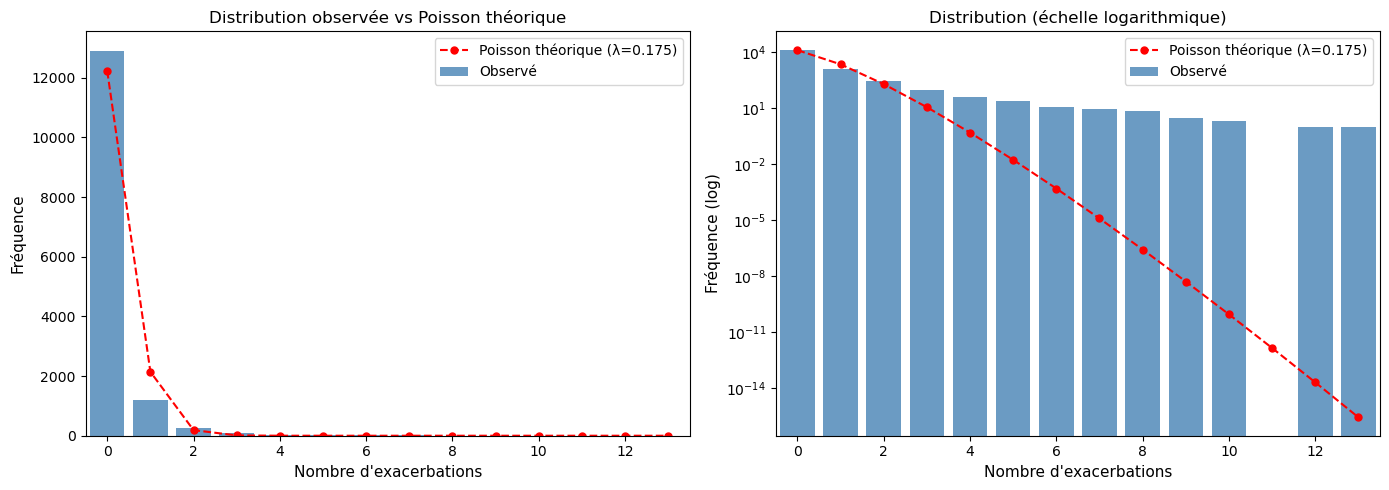

In [5]:
# Visualisation
lambda_est = y_counts.mean()
k_vals = np.arange(0, y_counts.max() + 1)
poisson_theoretical = stats.poisson.pmf(k_vals, mu=lambda_est) * len(y_counts)
counts_obs = y_counts.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, logy, title in zip(
    axes, [False, True],
    ['Distribution observée vs Poisson théorique', 'Distribution (échelle logarithmique)']
):
    ax.bar(counts_obs.index, counts_obs.values, color='steelblue', alpha=0.8, label='Observé')
    ax.plot(k_vals, poisson_theoretical, 'ro--', markersize=5, linewidth=1.5,
            label=f'Poisson théorique (λ={lambda_est:.3f})')
    if logy:
        ax.set_yscale('log')
        ax.set_ylabel('Fréquence (log)', fontsize=11)
    else:
        ax.set_ylabel('Fréquence', fontsize=11)
    ax.set_xlabel("Nombre d'exacerbations", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-0.5, min(y_counts.max() + 0.5, 15))
    ax.legend()
plt.tight_layout()
plt.show()

Les deux graphiques confirment que nos données ne suivent pas la loi de Poisson. On observe trop de patients sans exacerbation et, à l'opposé, des cas avec jusqu'à 13 exacerbations annuelles que Poisson considère comme quasi impossibles. Cet écart visible sur l'échelle logarithmique où les barres restent élevées là où la courbe rouge s'effondre est la signature d'une surdispersion.

# IV/ Préparation des données

On reprend les mêmes features que la partie 1. La variable cible reste en comptage brut non binarisée.

### Pondération des observations

Pour corriger le déséquilibre (87.5% de zéros), on calcule un poids pour chaque patient :
- Patients sans exacerbation → poids = 1
- Patients avec exacerbation → poids = ratio (nombre de 0 / nombre de 1)

Ce ratio correspond au déséquilibre observé dans les données. Ainsi, chaque exacerbation
compte autant dans l'entraînement que l'ensemble des patients sans exacerbation, forçant le modèle
à mieux apprendre ces cas rares sans les ignorer.

In [6]:
TARGET_COL = 'post_index_exacerbations365'

FEATURE_COLS = [
    'index_age', 'previous_asthma_drugs', 'total_pre_index_cannisters_365',
    'pneumonia', 'sinusitis', 'acute_bronchitis', 'acute_laryngitis',
    'upper_respiratory_infection', 'gerd', 'rhinitis', 'adherence',
    'total_pre_index_charge', 'pre_asthma_days', 'pre_asthma_charge',
    'pre_asthma_pharma_charge', 'drug_s', 'female'
]

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print(f'Features : {X.shape[1]} colonnes, {X.shape[0]} patients')
print(f'Cible    : min={y.min()}, max={y.max()}, moy={y.mean():.3f}')

Features : 17 colonnes, 14575 patients
Cible    : min=0, max=13, moy=0.175


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'X_train : {X_train.shape} / y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}  / y_test  : {y_test.shape}')

X_train : (11660, 17) / y_train : (11660,)
X_test  : (2915, 17)  / y_test  : (2915,)


In [8]:
categorical_features = [
    'previous_asthma_drugs', 'pneumonia', 'sinusitis', 'acute_bronchitis',
    'acute_laryngitis', 'upper_respiratory_infection', 'gerd', 'rhinitis',
    'drug_s', 'female'
]
numeric_features = [
    'index_age', 'total_pre_index_cannisters_365', 'adherence',
    'total_pre_index_charge', 'pre_asthma_days',
    'pre_asthma_charge', 'pre_asthma_pharma_charge'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Calcul des poids : ratio zéros/non-zéros
n_zeros   = (y_train == 0).sum()
n_nonzero = (y_train > 0).sum()
weight_ratio = n_zeros / n_nonzero
sample_weight_train = np.where(y_train > 0, weight_ratio, 1.0)

print(f'Patients sans exacerbation : {n_zeros} ({n_zeros/len(y_train)*100:.1f}%)')
print(f'Patients avec exacerbation : {n_nonzero} ({n_nonzero/len(y_train)*100:.1f}%)')
print(f'Poids appliqué aux cas positifs : {weight_ratio:.1f}')

Patients sans exacerbation : 10362 (88.9%)
Patients avec exacerbation : 1298 (11.1%)
Poids appliqué aux cas positifs : 8.0


# V/ Modèles de Machine Learning (ML) de comptage

On entraîne trois modèles couvrant les deux lois statistiques, avec pondération pour mieux
détecter les patients qui ont des exacerbations.

### Modèles Poisson

**Random Forest avec `criterion='poisson'`**

Minimise la déviance de Poisson à chaque nœud au lieu du MSE. Garantit des prédictions positives.

> **Limitation** : sklearn ne propose pas de critère `negative_binomial` pour les Random Forests.
> Le Random Forest reste sur Poisson c'est une contrainte de la bibliothèque. Il sert de référence.

**XGBoost avec `objective='count:poisson'`**

Optimise la log-vraisemblance de Poisson. Prédictions strictement positives via transformation interne.

---

### Modèle Binomiale Négative

**XGBoost avec `objective='reg:tweedie'` et `tweedie_variance_power=1.5`**

La distribution de Tweedie est paramétrée par `tweedie_variance_power` (p) :
- p = 1 → Poisson
- p = 1.5 → proche de la Binomiale Négative
- p = 2 → Gamma

En fixant p = 1.5, on autorise variance > moyenne, modélisant directement la surdispersion confirmée
en partie III.

Dans les trois cas, le `sample_weight` calculé dans la partie IV est passé à l'entraînement
pour forcer les modèles à mieux apprendre les cas avec exacerbations.

In [9]:
# V.1 Random Forest Poisson + pondération
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        criterion='poisson', n_estimators=200, random_state=42, n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['index_age',
                                                   'total_pre_index_cannisters_365',
                                                   'adherence',
                                                   'total_pre_index_charge',
                                                   'pre_asthma_days',
                                                   'pre_asthma_charge',
                                                   'pre_asthma_pharma_charge']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['previous_asthma_drugs',
                                                   'pneumonia', 'sinusitis',
                                                   'acute_bronchitis',
                                                   'acute_laryngitis',
                                                   'upper_respiratory_infection',
                                                   'gerd', 'rhinitis', 'drug_s',
                                                   'female'])])),
                ('model',
                 RandomForestRegressor(criterion='poisson', n_estimators=200,
                                       n_jobs=-1, random_state=42))])

In [10]:
# V.2 XGBoost Poisson + pondération
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(
        objective='count:poisson', n_estimators=200, learning_rate=0.05,
        max_depth=5, subsample=0.8, colsample_bytree=0.8,
        eval_metric='poisson-nloglik', random_state=42, n_jobs=-1
    ))
])
xgb_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['index_age',
                                                   'total_pre_index_cannisters_365',
                                                   'adherence',
                                                   'total_pre_index_charge',
                                                   'pre_asthma_days',
                                                   'pre_asthma_charge',
                                                   'pre_asthma_pharma_charge']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   Simp...
                              feature_weights=None, gamma=None,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [11]:
# V.3 XGBoost Binomiale Négative (Tweedie p=1.5) + pondération
nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(
        objective='reg:tweedie', tweedie_variance_power=1.5,
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='tweedie-nloglik@1.5', random_state=42, n_jobs=-1
    ))
])
nb_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['index_age',
                                                   'total_pre_index_cannisters_365',
                                                   'adherence',
                                                   'total_pre_index_charge',
                                                   'pre_asthma_days',
                                                   'pre_asthma_charge',
                                                   'pre_asthma_pharma_charge']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   Simp...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=-1,
                              num_parallel_tree=None, ...))])

# VI/ Optimisation des hyperparamètres (RandomizedSearch)

In [12]:
# RandomizedSearch : Random Forest
rf_param_grid = {
    'model__n_estimators':      randint(100, 400),
    'model__max_depth':         [None, 5, 10, 15, 20],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf':  randint(1, 10),
    'model__max_features':      ['sqrt', 'log2', 0.5]
}
rf_search = RandomizedSearchCV(
    rf_pipeline, param_distributions=rf_param_grid,
    n_iter=20, scoring='neg_mean_absolute_error',
    cv=5, random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train, model__sample_weight=sample_weight_train)
best_rf_pipeline = rf_search.best_estimator_
print(f'Meilleurs hyperparamètres RF : {rf_search.best_params_}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs hyperparamètres RF : {'model__max_depth': 20, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 8, 'model__n_estimators': 108}


In [13]:
# RandomizedSearch : XGBoost Poisson
xgb_param_grid = {
    'model__n_estimators':     randint(100, 400),
    'model__max_depth':        randint(3, 10),
    'model__learning_rate':    uniform(0.01, 0.2),
    'model__subsample':        uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 10)
}
xgb_search = RandomizedSearchCV(
    xgb_pipeline, param_distributions=xgb_param_grid,
    n_iter=20, scoring='neg_mean_absolute_error',
    cv=5, random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train, model__sample_weight=sample_weight_train)
best_xgb_pipeline = xgb_search.best_estimator_
print(f'Meilleurs hyperparamètres XGB Poisson : {xgb_search.best_params_}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs hyperparamètres XGB Poisson : {'model__colsample_bytree': 0.786705157299192, 'model__learning_rate': 0.18198808134726413, 'model__max_depth': 9, 'model__min_child_weight': 5, 'model__n_estimators': 266, 'model__subsample': 0.6053059844639466}


In [14]:
# RandomizedSearch : XGBoost Binomiale Négative (Tweedie)
# tweedie_variance_power est optimisé entre 1.1 et 1.9
nb_param_grid = {
    'model__n_estimators':           randint(100, 400),
    'model__max_depth':              randint(3, 10),
    'model__learning_rate':          uniform(0.01, 0.2),
    'model__subsample':              uniform(0.6, 0.4),
    'model__colsample_bytree':       uniform(0.6, 0.4),
    'model__min_child_weight':       randint(1, 10),
    'model__tweedie_variance_power': uniform(1.1, 0.8)
}
nb_search = RandomizedSearchCV(
    nb_pipeline, param_distributions=nb_param_grid,
    n_iter=20, scoring='neg_mean_absolute_error',
    cv=5, random_state=42, n_jobs=-1, verbose=1
)
nb_search.fit(X_train, y_train, model__sample_weight=sample_weight_train)
best_nb_pipeline = nb_search.best_estimator_
print(f'Meilleurs hyperparamètres NB Tweedie : {nb_search.best_params_}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs hyperparamètres NB Tweedie : {'model__colsample_bytree': 0.9706635463175177, 'model__learning_rate': 0.1554543991712842, 'model__max_depth': 9, 'model__min_child_weight': 8, 'model__n_estimators': 314, 'model__subsample': 0.8083337040103294, 'model__tweedie_variance_power': 1.8689376194794796}


# VII/ Evaluation des modèles
Pour évaluer les performances, on ne peut pas utiliser les mêmes métriques qu'en classification.
On s'appuie ici sur trois indicateurs adaptés aux données de comptage.
- Le **MAE** mesure en moyenne de combien d'exacerbations le modèle se trompe.
- Le **RMSE** pénalise davantage les grosses erreurs. Il est plus sensible aux patients pour lesquels le modèle prédit très mal.
- La **Déviance de Poisson** mesure à quel point les prédictions sont cohérentes avec la loi de Poisson.Plus elle est basse, meilleur est le modèle.

In [15]:
def poisson_deviance(y_true, y_pred):
    y_pred = np.maximum(y_pred, 1e-10)
    mask = y_true > 0
    d = np.zeros(len(y_true))
    d[mask] = y_true[mask] * np.log(y_true[mask] / y_pred[mask])
    d -= (y_true - y_pred)
    return 2 * d.sum() / len(y_true)

def evaluate_model(name, y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.maximum(np.array(y_pred), 0)
    return {
        'Modèle': name,
        'MAE':               round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE':              round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'Déviance Poisson':  round(poisson_deviance(y_true, y_pred), 4),
        '% 1 prédits':     round(((y_pred >= 0.5) & (y_pred < 1.5)).mean() * 100, 1),
        '% 1 observés':    round((y_true == 1).mean() * 100, 1),
        '% 0 prédits':   round((y_pred < 0.5).mean() * 100, 1),
        '% 0 observés':  round((y_true == 0).mean() * 100, 1)
    }

results_table = pd.DataFrame([
    evaluate_model('RF Poisson (base)',          y_test, rf_pipeline.predict(X_test)),
    evaluate_model('XGB Poisson (base)',         y_test, xgb_pipeline.predict(X_test)),
    evaluate_model('XGB Binomiale Neg. (base)',  y_test, nb_pipeline.predict(X_test)),
    evaluate_model('RF Poisson (optimisé)',      y_test, best_rf_pipeline.predict(X_test)),
    evaluate_model('XGB Poisson (optimisé)',     y_test, best_xgb_pipeline.predict(X_test)),
    evaluate_model('XGB Binomiale Neg. (opt.)',  y_test, best_nb_pipeline.predict(X_test)),
]).set_index('Modèle')

results_table

,MAE,RMSE,Déviance Poisson,% 1 prédits,% 1 observés,% 0 prédits,% 0 observés
Modèle,,,,,,,
RF Poisson (base),0.5578,0.7857,1.1367,35.7,9.1,64.3,87.5
XGB Poisson (base),0.6955,0.8713,1.3774,82.8,9.1,17.1,87.5
XGB Binomiale Neg. (base),0.5968,0.8271,1.2457,54.5,9.1,45.4,87.5
RF Poisson (optimisé),0.5764,0.7945,1.1659,44.9,9.1,55.1,87.5
XGB Poisson (optimisé),0.3261,0.7485,1.1305,5.0,9.1,95.0,87.5
XGB Binomiale Neg. (opt.),0.2278,0.7627,3.2546,1.2,9.1,98.7,87.5


In [16]:
# Sélection du meilleur modèle selon le MAE
y_pred_rf_opt  = best_rf_pipeline.predict(X_test)
y_pred_xgb_opt = best_xgb_pipeline.predict(X_test)
y_pred_nb_opt  = best_nb_pipeline.predict(X_test)

candidates = {
    'RF Poisson (optimisé)':      (mean_absolute_error(y_test, y_pred_rf_opt),  best_rf_pipeline,  y_pred_rf_opt),
    'XGB Poisson (optimisé)':     (mean_absolute_error(y_test, y_pred_xgb_opt), best_xgb_pipeline, y_pred_xgb_opt),
    'XGB Binomiale Neg. (opt.)':  (mean_absolute_error(y_test, y_pred_nb_opt),  best_nb_pipeline,  y_pred_nb_opt),
}
best_ml_name     = min(candidates, key=lambda k: candidates[k][0])
best_ml_pipeline = candidates[best_ml_name][1]
y_pred_best      = candidates[best_ml_name][2]

for name, (mae, _, _) in candidates.items():
    print(f'MAE {name:40s} : {mae:.4f}')
print(f'\nModèle retenu : {best_ml_name} (MAE = {candidates[best_ml_name][0]:.4f})')

MAE RF Poisson (optimisé)                    : 0.5764
MAE XGB Poisson (optimisé)                   : 0.3261
MAE XGB Binomiale Neg. (opt.)                : 0.2278

Modèle retenu : XGB Binomiale Neg. (opt.) (MAE = 0.2278)


Grâce à la pondération, les modèles accordent plus d'importance aux patients avec exacerbations lors de l'entraînement. On peut observer une amélioration du pourcentage de 1 prédits par rapport à un entraînement sans pondération.

Le modèle XGBoost binomiale négative est théoriquement le plus adapté grâce à sa gestion de la surdispersion. 

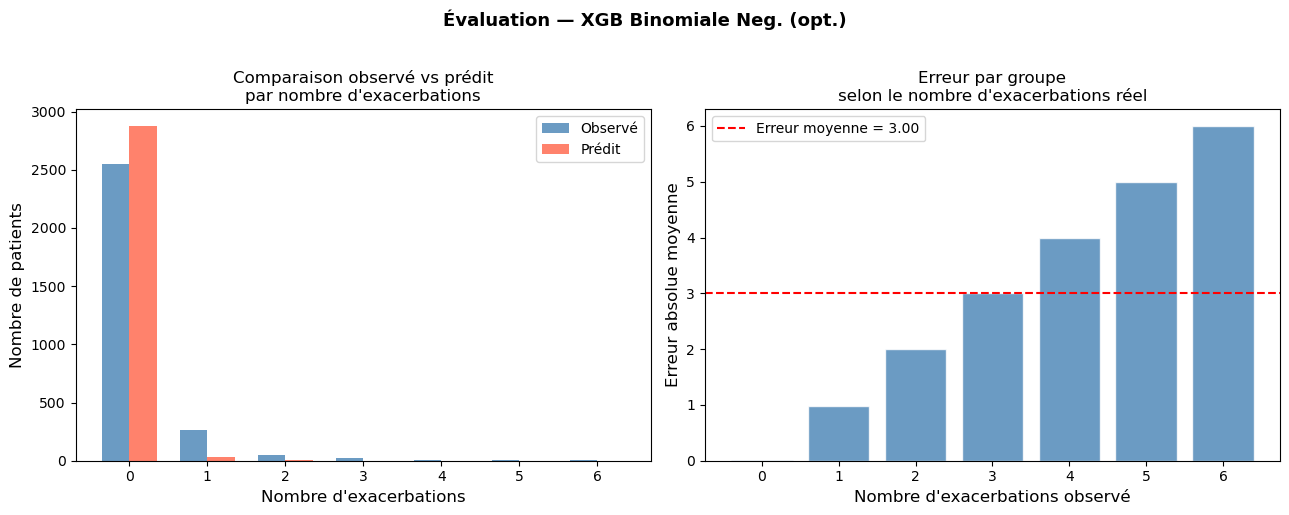

In [17]:
#Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

count_pred_rounded = np.round(y_pred_best).astype(int)
max_val = min(max(y_test.max(), count_pred_rounded.max()), 6)
bins = np.arange(0, max_val + 1)
obs_counts  = pd.Series(y_test.values).value_counts().sort_index().reindex(bins, fill_value=0)
pred_counts = pd.Series(count_pred_rounded).value_counts().sort_index().reindex(bins, fill_value=0)

x = np.arange(len(bins))
width = 0.35
axes[0].bar(x - width/2, obs_counts.values,  width, label='Observé', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, pred_counts.values, width, label='Prédit',  color='tomato',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(v) for v in bins])
axes[0].set_xlabel("Nombre d'exacerbations", fontsize=12)
axes[0].set_ylabel('Nombre de patients', fontsize=12)
axes[0].set_title("Comparaison observé vs prédit\npar nombre d'exacerbations", fontsize=12)
axes[0].legend()

df_eval = pd.DataFrame({'observé': y_test.values, 'prédit': count_pred_rounded})
df_eval['erreur'] = abs(df_eval['observé'] - df_eval['prédit'])
erreur_par_groupe = df_eval.groupby('observé')['erreur'].mean().head(7)

axes[1].bar(erreur_par_groupe.index, erreur_par_groupe.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axhline(y=erreur_par_groupe.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Erreur moyenne = {erreur_par_groupe.mean():.2f}')
axes[1].set_xlabel("Nombre d'exacerbations observé", fontsize=12)
axes[1].set_ylabel('Erreur absolue moyenne', fontsize=12)
axes[1].set_title("Erreur par groupe\nselon le nombre d'exacerbations réel", fontsize=12)
axes[1].legend()

plt.suptitle(f'Évaluation — {best_ml_name}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Graphique 1 : Comparaison observé vs prédit**

Grâce à la pondération, le modèle prédit davantage de patients avec exacerbations qu'un modèle
sans pondération. L'écart entre les barres bleues et roses pour les valeurs 1, 2, 3 est réduit.

**Graphique 2 : Erreur moyenne par groupe**

Plus un patient a d'exacerbations réelles, plus le modèle se trompe. La pondération améliore
surtout les groupes 1 et 2. Les cas très sévères (> 5 exacerbations) restent difficiles à prédire
en raison de leur très faible effectif dans les données.

# VIII/ AMÉLIORATION PAR APPROCHE EN CASCADE

Même si la pondération aide les modèles, elle ne suffit pas à bien gérer le grand nombre de patients n'ayant aucune crise. Pour cela, nous utilisons une **approche en cascade** (ou « en entonnoir ») qui combine les deux projet. Il consiste à commencer par utiliser le modèle de classification pour filtrer les patients, s'il prédit qu'un patient est à risque (seuil de 0,47 dans le projet 1), un second modèle de comptage (Poisson ou Binomiale Négative) prend le relais pour estimer précisément son nombre d'exacerbations. En revanche, si le premier modèle juge le patient sans risque, on lui attribue directement la valeur 0.

> **Différence de features** : le projet 1 exclut `total_pre_index_charge` et `pre_asthma_charge`
> mais inclut `log_charges` et `log_asthma_charge`. On utilise les features propres à chaque modèle.

In [18]:
# Reconstruction du modèle de classification (partie 1)
# Meilleurs hyperparamètres issus du GridSearch de la partie 1
FEATURE_COLS_PART1 = [
    'index_age', 'previous_asthma_drugs', 'total_pre_index_cannisters_365',
    'pneumonia', 'sinusitis', 'acute_bronchitis', 'acute_laryngitis',
    'upper_respiratory_infection', 'gerd', 'rhinitis', 'adherence',
    'pre_asthma_days', 'pre_asthma_pharma_charge',
    'drug_s', 'female', 'log_charges', 'log_asthma_charge'
]
SEUIL_PART1 = 0.47

y_bin = (df['post_index_exacerbations365'] > 0).astype(int)
X_part1 = df[FEATURE_COLS_PART1]

X_train_p1, X_test_p1, y_train_p1, _ = train_test_split(
    X_part1, y_bin, test_size=0.20, stratify=y_bin, shuffle=True, random_state=42
)

classif_model = Pipeline([
    ('imputer', IterativeImputer(max_iter=10, random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=275, max_depth=3, min_samples_split=8,
        min_samples_leaf=2, max_features='sqrt',
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    ))
])
classif_model.fit(X_train_p1, y_train_p1)

Pipeline(steps=[('imputer', IterativeImputer(random_state=42)),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=3, min_samples_leaf=2,
                                        min_samples_split=8, n_estimators=275,
                                        n_jobs=-1, random_state=42))])

In [19]:
# Application de la cascade sur le jeu de test
X_test_p1_aligned = df.loc[X_test.index, FEATURE_COLS_PART1]
y_proba_classif   = classif_model.predict_proba(X_test_p1_aligned)[:, 1]
y_classif         = (y_proba_classif >= SEUIL_PART1).astype(int)
mask_at_risk      = y_classif == 1

y_cascade = np.zeros(len(X_test), dtype=int)
if mask_at_risk.sum() > 0:
    lambda_risk = best_ml_pipeline.predict(X_test[mask_at_risk])
    lambda_risk = np.maximum(lambda_risk, 1)  # au moins 1 car classifié positif
    y_cascade[mask_at_risk] = np.round(lambda_risk).astype(int)

print(f'Patients classifiés à risque (partie 1) : {mask_at_risk.sum()} ({mask_at_risk.mean()*100:.1f}%)')
print(f'Patients classifiés sans risque          : {(~mask_at_risk).sum()} ({(~mask_at_risk).mean()*100:.1f}%)')

Patients classifiés à risque (partie 1) : 2065 (70.8%)
Patients classifiés sans risque          : 850 (29.2%)


In [20]:
# Comparaison : meilleur modèle seul vs cascade
results_cascade = pd.DataFrame([
    evaluate_model(f'{best_ml_name} seul',  y_test, y_pred_best),
    evaluate_model('Approche en cascade',   y_test, y_cascade),
]).set_index('Modèle')

results_cascade

,MAE,RMSE,Déviance Poisson,% 1 prédits,% 1 observés,% 0 prédits,% 0 observés
Modèle,,,,,,,
XGB Binomiale Neg. (opt.) seul,0.2278,0.7627,3.2546,1.2,9.1,98.7,87.5
Approche en cascade,0.7129,0.9734,2.9982,70.7,9.1,29.2,87.5


Le modèle seul (XGBoost Binomiale Négative) prédit très peu de patients avec exacerbations (1.2% de 1 prédits contre 9.1% réels), mais reste précis en moyenne (MAE = 0.23). L'approche en cascade améliore fortement la détection des cas positifs (70.7% de uns prédits) et réduit la déviance de Poisson, mais au prix d'une erreur moyenne plus élevée (MAE = 0.71), car elle prédit désormais des exacerbations là où le modèle seul aurait mis zéro. Selon l'objectif clinique, si l'on veut avant tout ne pas manquer les patients à risque, la cascade est préférable cependant si l'on veut une estimation précise du nombre, le modèle seul est plus fiable.

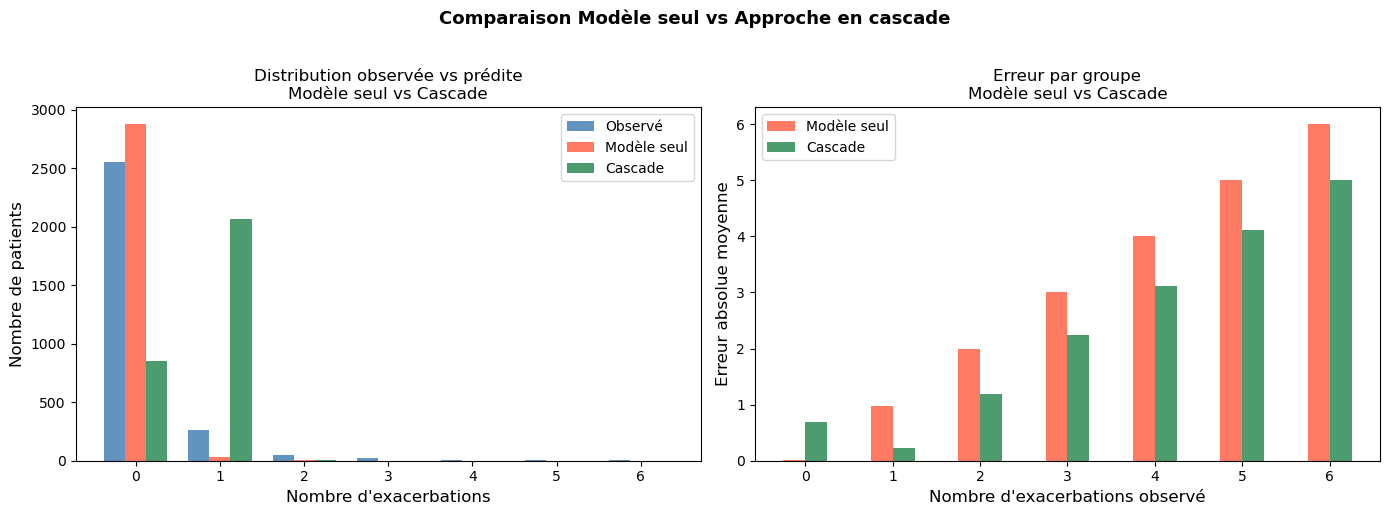

In [21]:
# Visualisation comparative : 3 barres (observé / modèle seul / cascade)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_val = 6
bins = np.arange(0, max_val + 1)
x = np.arange(len(bins))
width = 0.25

obs_c     = pd.Series(y_test.values).value_counts().sort_index().reindex(bins, fill_value=0)
single_c  = pd.Series(np.round(y_pred_best).astype(int)).value_counts().sort_index().reindex(bins, fill_value=0)
cascade_c = pd.Series(y_cascade).value_counts().sort_index().reindex(bins, fill_value=0)

axes[0].bar(x - width, obs_c.values,     width, label='Observé',       color='steelblue', alpha=0.85)
axes[0].bar(x,         single_c.values,  width, label='Modèle seul',   color='tomato',    alpha=0.85)
axes[0].bar(x + width, cascade_c.values, width, label='Cascade',       color='seagreen',  alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(v) for v in bins])
axes[0].set_xlabel("Nombre d'exacerbations", fontsize=12)
axes[0].set_ylabel('Nombre de patients', fontsize=12)
axes[0].set_title('Distribution observée vs prédite\nModèle seul vs Cascade', fontsize=12)
axes[0].legend()

df_comp = pd.DataFrame({'obs': y_test.values,
                        'single': np.round(y_pred_best).astype(int),
                        'cascade': y_cascade})
err_s = df_comp.groupby('obs').apply(lambda g: abs(g['obs'] - g['single']).mean()).head(7)
err_c = df_comp.groupby('obs').apply(lambda g: abs(g['obs'] - g['cascade']).mean()).head(7)

x2 = np.arange(len(err_s))
axes[1].bar(x2 - width/2, err_s.values, width, label='Modèle seul', color='tomato',   alpha=0.85)
axes[1].bar(x2 + width/2, err_c.values, width, label='Cascade',     color='seagreen', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels([str(v) for v in err_s.index])
axes[1].set_xlabel("Nombre d'exacerbations observé", fontsize=12)
axes[1].set_ylabel('Erreur absolue moyenne', fontsize=12)
axes[1].set_title('Erreur par groupe\nModèle seul vs Cascade', fontsize=12)
axes[1].legend()

plt.suptitle('Comparaison Modèle seul vs Approche en cascade', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Graphique 1 : le modèle seul (rose) prédit quasi des zéros, ratant presque tous les patients avec 1 exacerbation ou plus. La cascade (vert) corrige cela de façon spectaculaire pour les patients avec 1 exacerbation, mais crée un nouveau déséquilibre : elle prédit trop de 1 (environ 2 000) par rapport à la réalité (environ 300).

Graphique 2 : la cascade réduit fortement l'erreur pour les groupes 1 et 2 exacerbations par rapport au modèle seul. En revanche, pour les groupes 3 à 6, les deux approches restent imprécises, avec des erreurs importantes qui s'expliquent par le très faible nombre de patients dans ces groupes.

# IX/ PRÉDICTION SUR UN NOUVEAU FICHIER

**Remplacer `NEW_FILE` par le chemin du nouveau fichier.**

La prédiction utilise l'**approche en cascade** : classification (partie 1) puis comptage (partie 2).

Le fichier CSV de sortie contient :
- `patid` : identifiant du patient
- `prediction` : nombre d'exacerbations prédit dans l'année (entier)

In [24]:
NEW_FILE = "trainData.csv.gz"  # <- Remplacer ICI par le nouveau fichier

df_new = pd.read_csv(NEW_FILE, sep=",")
print(f'Fichier chargé : {df_new.shape[0]} patients, {df_new.shape[1]} variables')

# Recalcul des colonnes dérivées si absentes du nouveau fichier
# (nécessaires pour le modèle de classification de la partie 1)
if 'log_charges' not in df_new.columns:
    df_new['log_charges'] = np.log1p(df_new['total_pre_index_charge'].fillna(0))
    print('log_charges recalculée.')
if 'log_asthma_charge' not in df_new.columns:
    df_new['log_asthma_charge'] = np.log1p(df_new['pre_asthma_charge'].fillna(0))
    print('log_asthma_charge recalculée.')

# Étape 1 : classification (partie 1) avec seuil 0.47
X_new_p1    = df_new[FEATURE_COLS_PART1]
y_proba_new = classif_model.predict_proba(X_new_p1)[:, 1]
mask_risk   = (y_proba_new >= SEUIL_PART1)

# Étape 2 : comptage Poisson/NB pour les patients à risque
X_new_p2       = df_new[FEATURE_COLS]
count_pred_new = np.zeros(len(df_new), dtype=int)
if mask_risk.sum() > 0:
    lambda_risk = best_ml_pipeline.predict(X_new_p2[mask_risk])
    lambda_risk = np.maximum(lambda_risk, 1)  # au moins 1 car classifié positif
    count_pred_new[mask_risk] = np.round(lambda_risk).astype(int)

# Export CSV : patid + prediction (entier naturel)
results_new = pd.DataFrame({
    'patid':      df_new['patid'],
    'prediction': count_pred_new.astype(int)
})
results_new.to_csv('predictions_poisson.csv', index=False)

print(f'\n Résultats : Approche en cascade')
print(f'Patients classifiés à risque     : {mask_risk.sum()} ({mask_risk.mean()*100:.1f}%)')
print(f'Patients prédits 0 exacerbation  : {(count_pred_new==0).sum()} ({(count_pred_new==0).mean()*100:.1f}%)')
print(f'Patients prédits >=1 exacerbation: {(count_pred_new>=1).sum()} ({(count_pred_new>=1).mean()*100:.1f}%)')
print(f'Nombre moyen prédit              : {count_pred_new.mean():.4f}')
print(f'\nDistribution des prédictions :')
print(pd.Series(count_pred_new, name='prediction').value_counts().sort_index().head(10).to_string())
print('\nAperçu :')
print(results_new.head(10).to_string(index=False))

from IPython.display import FileLink
FileLink('predictions_poisson.csv')

Fichier chargé : 14575 patients, 21 variables

 Résultats : Approche en cascade
Patients classifiés à risque     : 10378 (71.2%)
Patients prédits 0 exacerbation  : 4197 (28.8%)
Patients prédits >=1 exacerbation: 10378 (71.2%)
Nombre moyen prédit              : 0.7371

Distribution des prédictions :
prediction
0     4197
1    10166
2      132
3       47
4       17
5        5
6        6
7        1
8        2
9        1

Aperçu :
     patid  prediction
1073754155           1
1073799394           2
1073854918           0
1073898249           1
1073913003           0
1073928980           1
1074030062           1
1074078078           1
1074166886           0
1074184402           1


C:\Users\flora\Data_chII\predictions_poisson.csv